### [Transformer Architecture]
- RNN을 제거하고(순차적 처리 상실) 오직 attention 연산만으로 병렬적 seq2seq구조를 구현한 모델
- attention을 극대화(self-attention)하여 병렬 처리 가능 ->맥락을 더 잘 이해, 현대 LLM의 모태

encoder
- embedding + 기존 임베딩값에 대해 위치 인코딩(positional encoding, Sine Cosine 함수 형태) = 위치+방향 값

- 기존 '나는' '너를' '사랑해' 로 순서가 있는 학습 방식이었다면, transformer는 '나는너를사랑해' 한꺼번에 학습, 하지만 위치를 기억해야 하기 때문에 위치 인코딩이 추가됨

in a multi-head attention head...(여러개의 평가자가 있다고 생각, 평가자 여러명이면 편향되지 않은 평가를 내릴 수 있음. 여러평가를 종합(압축))
- query, key vector -> attention weight 
- attention weight * value vector -> context vector

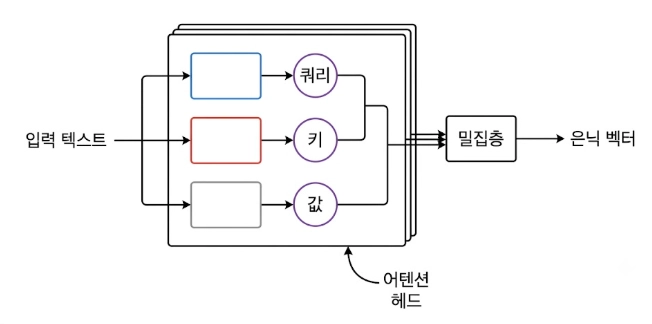

`밀집층`: 입력 데이터의 차원(크기)를 원하는 대로 바꾸면서, 가중치w를 통해 데이터 재가공, 특성 추출하는 변환기-> 맥락을 전부 담고 있다

`잔차연결(residual connection)`
- 가중치 많을수록 (층이 많을수록) 값이 적어져 기울기 소실 -> 학습 효율이 떨어지고 불안정해짐
- 서브레이어(어텐션 등) 드롭아웃 (->과적합 방지) + 초기입력정보 잔차연결
- 층이 깊어져도 초기 입력 정보와 기울기가 손실 없이 원형 그대로 깊은 층까지 전달되도록 만듦, 증폭
- "초기 입력값의 정보와 기울기가 끊기지 않도록 보존하는 지름길"

`층 정규화`
- 잔차연결 이후 입력값이 계속 더해지고 층을 통과하다 보면 숫자들이 증폭(크기, 분포 들쭉날쭉)
- 단어벡터 내부 숫자를 '평균 0, 표준편차 1'로 정돈하여 튀는 데이터 값을 안정시킴
- "지름길 지난 숫자들이 폭주하지 않도록 고르게 펴주는 안정화 장치"

`피드 포워드 네트워크`
- 밀집층 - ReLU - 밀집층 - 드롭아웃
- vector - 심층 가공 (팽창 - 다시 원래 크기로 압축) by nn.Linear()

`인코더 블록`
- 중첩해서 만들기 가능
- 입력차원과 출력차원이 동일함

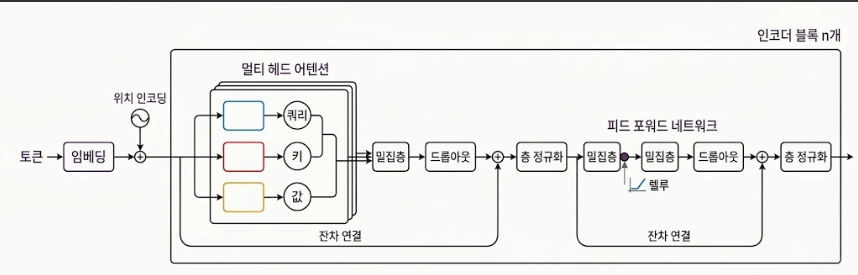

# 6장 1강: 트랜스포머 아키텍쳐
## 3. 임베딩과 위치 인코딩(Positional Encoding)

### 3.4 PyTorch 코드 구현(임베딩부터 위치 주입까지)

In [4]:
import math
import torch
import torch.nn as nn

class TransformerInputPipeline(nn.Module):
    """토큰 생성 -> 임베딩 변환 -> 한꺼번에 입력 -> 위치 신호 합산의 전체 흐름 구현"""
    def __init__(self, vocab_size, d_model, max_len=5000):
        super().__init__()
        # [단계 1] 단어의 의미적 좌표를 정해주는 임베딩 레이어 정의
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model
        
        # [단계 2] 고정된 위치 번호표(PE) 행렬 미리 계산 및 생성
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term) # 짝수 인덱스 사인 적용
        pe[:, 1::2] = torch.cos(position * div_term) # 홀수 인덱스 코사인 적용
        
        # 상수가 업데이트되지 않도록 버퍼 저장 공간에 고정
        self.register_buffer('pe', pe.unsqueeze(0)) 

    def forward(self, tokens):
        # tokens shape: [Batch_Size, Seq_Len]
        
        # [단계 1 & 2] 토큰장을 거쳐 순서 감각이 없는 병렬 임베딩 텐서 생성
        embeds = self.embedding(tokens) * math.sqrt(self.d_model)
        
        # [단계 3] 도식의 (+) 기호와 같이, 임베딩 위에 위치 정보 신호를 그대로 합산
        # embeds: [Batch, Seq_Len, d_model]  +  pe: [1, Seq_Len, d_model]
        final_inputs = embeds + self.pe[:, :embeds.size(1)]
        
        return final_inputs

## 4. 핵심 엔진: 셀프 어텐션과 Q, K, V의 이해
### 4.4 PyTorch 코드 구현(멀티 헤드 어텐션)

In [5]:
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    """Q, K, V 생성 및 멀티 헤드 분할/병합을 수행하는 어텐션 모듈"""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads # 각 헤드가 담당할 차원 크기
        
        # 입력 텐서를 Q, K, V로 변환하기 위한 3개의 가중치 행렬(밀집층)-입력 단어 벡터를 전달받아 Q, K, V로 변환해줌
        self.q_linear = nn.Linear(d_model, d_model, bias=False)
        self.k_linear = nn.Linear(d_model, d_model, bias=False)
        self.v_linear = nn.Linear(d_model, d_model, bias=False)
        
        # 여러 개로 쪼개진 헤드들을 다시 합쳐서 최종 출력으로 변환하는 밀집층, 값을 압축: 멀티헤드 어텐션 출력 병합 by out_linear
        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        # 밀집층 투사 후 차원을 고차원으로 분할하여 다수의 헤드(num_heads) 생성
        # [Batch, Seq, d_model] -> [Batch, Heads, Seq, Head_Dim]
        q = self.q_linear(query).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_linear(key).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_linear(value).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        
        # 예시 분석과 동일하게 Q와 K^T를 곱해 스케일링 점수 도출
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        """ 마스킹 필터 적용
        # - mask가 0인 위치(가려야 할 영역)의 점수를 -1e9(마이너스 10억)라는 극단적인 음수로 바꿉니다.
        # - 바로 다음 줄의 Softmax 연산 시, e^(-10억)은 수학적으로 0에 수렴하게 됩니다.
        # - 결과적으로 모델이 해당 토큰의 정보를 전혀 반영하지 못하게(어텐션 가중치 = 0) 차단하는 역할을 합니다.
        # - 용도: 1) 디코더의 미래 토큰 커닝 방지(Causal Mask) 2) 의미 없는 패딩 토큰 무시(Padding Mask)""" 
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        # Softmax 정규화 확률화 계산 후 V 행렬곱 결합
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(self.dropout(attn_weights), v)
        
        # 멀티 헤드 결합 기법: 분리되어 있던 헤드들을 가로로 복원 병합(Concat)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        return self.out_linear(context)

## 5. 토큰별 피드포워드 네트워크 (Positionwise FFN)
### 5.1 PyTorch 코드 구현

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionwiseFeedForward(nn.Module):
    """토큰별로 독립적으로 적용되는 비선형 심층 밀집층"""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff) # 차원 팽창 (예: 512 -> 2048)
        self.w_2 = nn.Linear(d_ff, d_model) # 차원 압축 복원 (예: 2048 -> 512)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 첫 번째 밀집층을 통과하며 차원을 확장합니다.
        out = self.w_1(x)
        
        # 비선형 활성화 함수(ReLU)를 적용합니다.
        out = F.relu(out)
        
        # 두 번째 밀집층을 통과하며 원래 차원으로 복원합니다.
        out = self.w_2(out)
        
        # 잔차 연결(더하기) 직전, 최종 출력값에 드롭아웃을 적용합니다.
        out = self.dropout(out)
        
        return out

## 6. 인코더(Encoder) 블록의 조립
### 6.2 PyTorch 코드 구현

In [7]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 서브레이어 1: 셀프 어텐션 영역 연산
        residual = x  # 잔차연결 값: 원래 입력값 보존
        attn_out = self.self_attn(query=x, key=x, value=x, mask=mask)
        # 잔차 합산(⊕)을 먼저 수행한 뒤 층 정규화 상자로 진입
        x = self.norm1(residual + self.dropout(attn_out))
        
        # 서브레이어 2: 피드 포워드 네트워크 영역 연산
        residual = x  # 두 번째 우회 고속도로선: 어텐션 정제 완료값 보존
        ff_out = self.feed_forward(x)
        # 잔차 합산(⊕) 후 최종 층 정규화 통과
        x = self.norm2(residual + self.dropout(ff_out))
        return x

## 7. 디코더(Decoder) 블록의 조립
### 7.2 PyTorch 코드 구현

In [8]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.masked_self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # 마스크드 셀프 어텐션 (미래 단어 컨닝 방지용 tgt_mask 적용)
        residual = x
        self_attn_out = self.masked_self_attn(query=x, key=x, value=x, mask=tgt_mask)
        x = self.norm1(residual + self.dropout(self_attn_out))
        
        # 크로스 어텐션 (Query: 디코더 변환값 x / Key, Value: 인코더 최상단 기둥의 enc_output)
        residual = x
        cross_attn_out = self.cross_attn(query=x, key=enc_output, value=enc_output, mask=src_mask)
        x = self.norm2(residual + self.dropout(cross_attn_out))
        
        # 피드 포워드 네트워크
        residual = x
        ff_out = self.feed_forward(x)
        x = self.norm3(residual + self.dropout(ff_out))
        return x

## 8. 인코더-디코더 결합망: 전체 트랜스포머 아키텍처 완성
### 8.2 PyTorch 코드 구현(통합 조립 및 실행 검증)

인코더-디코터 결합망 구성하기

In [11]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# (위에서 정의한 PositionalEncoding, TransformerInputPipeline, 
#  MultiHeadAttention, PositionwiseFeedForward, 
#  TransformerEncoderLayer, TransformerDecoderLayer 클래스들이 모두 선언되어 있습니다.)

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()
        self.input_pipeline = TransformerInputPipeline(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        
    def forward(self, src, mask=None):
        x = self.input_pipeline(src)
        for layer in self.layers:
            x = layer(x, mask)
        return x


class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()
        self.input_pipeline = TransformerInputPipeline(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        
    def forward(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        x = self.input_pipeline(tgt)
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x


class FullTransformer(nn.Module):
    """최종 조립된 트랜스포머 아키텍처 모델"""
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_layers=2, num_heads=8, d_ff=1024, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, dropout)
        self.decoder = TransformerDecoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, dropout)
        self.projection = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output = self.encoder(src, src_mask)
        dec_output = self.decoder(tgt, enc_output, src_mask, tgt_mask)
        return self.projection(dec_output)


컴포넌트 구조 및 정상 작동 확인

In [10]:

SRC_VOCAB, TGT_VOCAB = 4000, 4000
D_MODEL, NUM_HEADS, D_FF, LAYERS = 256, 4, 1024, 2
    
transformer_model = FullTransformer(
    src_vocab_size=SRC_VOCAB, tgt_vocab_size=TGT_VOCAB, 
    d_model=D_MODEL, num_layers=LAYERS, num_heads=NUM_HEADS, d_ff=D_FF
)
    
print("=" * 70)
print(f"       [트랜스포머 서브 컴포넌트 전체 조립 완료 및 구조 보고서]       ")
print("=" * 70)
    
breakdown = {"Encoder": 0, "Decoder": 0, "Final Projection": 0}
    
for name, param in transformer_model.named_parameters():
    if param.requires_grad:
        num_param = param.numel()
        if "encoder" in name: breakdown["Encoder"] += num_param
        elif "decoder" in name: breakdown["Decoder"] += num_param
        elif "projection" in name: breakdown["Final Projection"] += num_param
                
        if 'weight' in name and any(k in name for k in ['linear', 'w_', 'embedding', 'projection']):
            print(f"▷ 계층 구성 정보: {name:<50} | 파라미터 수: {num_param:,}개")
                
print("-" * 70)
print(f"■ 인코더 기둥 파라미터 소계  : {breakdown['Encoder']:,} 개")
print(f"■ 디코더 기둥 파라미터 소계  : {breakdown['Decoder']:,} 개")
print(f"■ 최종 선형 투사층 파라미터  : {breakdown['Final Projection']:,} 개")
print(f"★ 트랜스포머 전체 파라미터 총계: {sum(breakdown.values()):,} 개")
print("=" * 70)

# 가상 차원 추적 테스트 진행 (더미 데이터 주입)
print("\n[데이터 연산 흐름 및 텐서 차원 검증]")
batch_size, src_len, tgt_len = 2, 5, 6
dummy_src = torch.randint(0, SRC_VOCAB, (batch_size, src_len))
dummy_tgt = torch.randint(0, TGT_VOCAB, (batch_size, tgt_len))
    
causal_mask = torch.tril(torch.ones(tgt_len, tgt_len)).unsqueeze(0).unsqueeze(1)
    
output = transformer_model(dummy_src, dummy_tgt, src_mask=None, tgt_mask=causal_mask)
print(f"1. 입력 소스(Source) 시퀀스 차원    (Batch, Src_Len)     : {dummy_src.shape}")
print(f"2. 입력 타깃(Target) 시퀀스 차원    (Batch, Tgt_Len)     : {dummy_tgt.shape}")
print(f"3. 인과 마스킹 텐서 차원 크기        (Batch, 1, Tgt, Tgt) : {causal_mask.shape}")
print(f"4. 트랜스포머 전방향 최종 출력 차원 (Batch, Tgt_Len, Vocab): {output.shape} -> [정상 작동]")

       [트랜스포머 서브 컴포넌트 전체 조립 완료 및 구조 보고서]       
▷ 계층 구성 정보: encoder.input_pipeline.embedding.weight            | 파라미터 수: 1,024,000개
▷ 계층 구성 정보: encoder.layers.0.self_attn.q_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.0.self_attn.k_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.0.self_attn.v_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.0.self_attn.out_linear.weight       | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.0.feed_forward.w_1.weight           | 파라미터 수: 262,144개
▷ 계층 구성 정보: encoder.layers.0.feed_forward.w_2.weight           | 파라미터 수: 262,144개
▷ 계층 구성 정보: encoder.layers.1.self_attn.q_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.1.self_attn.k_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.1.self_attn.v_linear.weight         | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.1.self_attn.out_linear.weight       | 파라미터 수: 65,536개
▷ 계층 구성 정보: encoder.layers.1.feed_forward.w_1.weight    